# Preprocessing

In [1]:
import pandas as pd
import numpy as np
import os
import json
import kagglehub
import warnings
import traceback
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

import itertools
import random

# Load preprocessing classes
os.chdir('../')  # Change to project root directory
# Preprocessing and utility imports
from utils.preprocessing.CarDatabase import ProductionCarMatcher, create_optimized_database
from utils.preprocessing.Cardinal_Preprocessor import CardinalMapper



print("SIMPLE ML TEMPLATE - FAST CLEAN DATA")
print("=" * 45)


param_grid_svr = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}


# CONFIGURATION - Change these as needed
CONFIG = {

    'random_state': 42,
    'target_column': 'price',
    
    # Preprocessing options
    'outlier_removal': True,          # Remove outliers?
    'feature_scaling': True,          # Scale features?
    'encoding_method': 'onehot',        # 'mean', 'onehot'
    
    # Feature transformations
    'log_transform_mileage': True,    # Log transform mileage?
    'convert_year_to_age': True,      # Convert year to car age?
    'normalize_paint': True,          # Normalize paint quality to 0-1?
    'normalize_engine': True,         # Convert engine size units?
    
    # Data splitting
    'test_size': 0.2,                 # Proportion of data for testing
    'feature_selection_size': 0.16,   # Proportion of training data for feature selection
    
    # Model selection
    'n_splits': 5,                   # Number of reppetead K-Fold splits
    'n_repeats': 5,                  # Number of repeats for K-Fold
    
    # Toggle a short search for fast iteration (set to False for full grid)
    'SHORT_SEARCH': False,
    'MAX_COMBINATIONS': 3,                              # when SHORT_SEARCH=True, sample up to this many combinations
    'model_class': RandomForestRegressor,               # can be SVR, RandomForestRegressor, MLPRegressor
    'param_grid': param_grid_rf                        # can be param_grid_svr, param_grid_rf, etc.
}
if CONFIG['SHORT_SEARCH']:
    CONFIG['n_splits'] = 2
    CONFIG['n_repeats'] = 2
    print("WARNING: SHORT_SEARCH is enabled. Using a subset of data and parameter combinations for quick testing, not for final evaluation.")
print(f"Configuration: {CONFIG}")

SIMPLE ML TEMPLATE - FAST CLEAN DATA
Configuration: {'random_state': 42, 'target_column': 'price', 'outlier_removal': True, 'feature_scaling': True, 'encoding_method': 'onehot', 'log_transform_mileage': True, 'convert_year_to_age': True, 'normalize_paint': True, 'normalize_engine': True, 'test_size': 0.2, 'feature_selection_size': 0.16, 'n_splits': 5, 'n_repeats': 5, 'SHORT_SEARCH': False, 'MAX_COMBINATIONS': 3, 'model_class': <class 'sklearn.ensemble._forest.RandomForestRegressor'>, 'param_grid': {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}}


In [2]:
# Load datasets and quick sanity checks
raw_train_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\train.csv')
test_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\test.csv')
if CONFIG['SHORT_SEARCH']:
    raw_train_data = raw_train_data.sample(n=500, random_state=CONFIG['random_state']).reset_index(drop=True)
    test_data = test_data.sample(n=200, random_state=CONFIG['random_state']).reset_index(drop=True)

print(f"Loaded: train -> {raw_train_data.shape}, test -> {test_data.shape}")

print('\n--- Train dtypes ---')
print(raw_train_data.dtypes)

print('\n--- Train head (5 rows) ---')
display(raw_train_data.head(5))

print('\n--- Top 10 missing counts (train) ---')
print(raw_train_data.isnull().sum().sort_values(ascending=False).head(10))

missing_pct = (raw_train_data.isnull().mean() * 100).sort_values(ascending=False).head(10)
print('\n--- Top 10 missing percent (train) ---')
print(missing_pct.round(2))

# Keep canonical variable names used later in the notebook
train_data = raw_train_data.copy()


Loaded: train -> (75973, 14), test -> (32567, 13)

--- Train dtypes ---
carID               int64
Brand              object
model              object
year              float64
price               int64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object

--- Train head (5 rows) ---


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0



--- Top 10 missing counts (train) ---
mpg               7926
tax               7904
previousOwners    1550
hasDamage         1548
paintQuality%     1524
transmission      1522
Brand             1521
model             1517
engineSize        1516
fuelType          1511
dtype: int64

--- Top 10 missing percent (train) ---
mpg               10.43
tax               10.40
previousOwners     2.04
hasDamage          2.04
paintQuality%      2.01
transmission       2.00
Brand              2.00
model              2.00
engineSize         2.00
fuelType           1.99
dtype: float64


In [3]:
raw_train_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\train.csv')
test_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\test.csv')
path = kagglehub.dataset_download("bourzamraid/global-car-make-and-model-list")
with open(os.path.join(path, 'vehicle models.json'), 'r') as f:
    kaggle_data = json.load(f)
        
# Create matcher and clean brands
optimized_db = create_optimized_database(kaggle_data, max_model_words=3)
matcher = ProductionCarMatcher(optimized_db)
        
_, train_data_results  =  matcher.clean_dataframe(raw_train_data,
                                        'Brand',
                                        'model')
_, test_data_results  =  matcher.clean_dataframe(test_data,
                                        'Brand',
                                        'model')
# concat the cleaned data with the target column
train_data = pd.concat([raw_train_data.loc[train_data_results.index], train_data_results[['clean_make', 'clean_model']]], axis=1)
test_data = pd.concat([test_data.loc[test_data_results.index], test_data_results[['clean_make', 'clean_model']]], axis=1)
# dorp Brand and model columns
train_data = train_data.drop(columns=['Brand', 'model'])
test_data = test_data.drop(columns=['Brand', 'model'])

fueltype_dict = {
    'Petrol': (['petrol', 'petro', 'etrol', 'etro', 'petr', 'ptrol' ],
               [ 'diesel', 'hybrid', 'electric',  'other' ]),
    'Diesel': (['diesel', 'diese', 'iesel', 'iese', 'dise' ],
               [ 'petrol', 'hybrid', 'electric',  'other' ]),
    'Hybrid': (['hybrid', 'hybri', 'ybrid', 'ybri', 'hyb' ],
               [ 'petrol', 'diesel', 'electric',  'other' ]),
    'Electric': (['electric', 'elect', 'elec' ],
               [ 'petrol', 'diesel', 'hybrid',  'other' ]),
    'Other': (['other', 'othe', 'oth' ],
               [ 'petrol', 'diesel', 'hybrid',  'electric' ]) }

transmission_dict = {
    'Manual': ([ 'man', 'manual', 'm', 'stick', 'standard', 'mt' ],
               [ 'auto', 'semi', 'automatic', 'tiptronic', 'emi','mi','other' ]),
    'Semi-Auto': (['semi', 'semi-auto', 'tiptronic', 'emi','mi' ],
                    [ 'manual', 'stick', 'full manual', 'Other' ]),
    'Automatic': (['auto', 'automatic', 'a', 'at' ],
                  [ 'semi', 'manual', 'stick', 'tiptronic', 'emi','mi', 'other' ]) }


fuel_mapper = CardinalMapper(fueltype_dict)
transmission_mapper = CardinalMapper(transmission_dict)

print("Mapping fuelType and transmission columns...")
train_data['fuelType'] = fuel_mapper.fit_transform(train_data['fuelType'])
train_data['transmission'] = transmission_mapper.fit_transform(train_data['transmission'])
print(f"fuelType value counts:\n{train_data['fuelType'].value_counts()}")
test_data['fuelType'] = fuel_mapper.fit_transform(test_data['fuelType'])
test_data['transmission'] = transmission_mapper.fit_transform(test_data['transmission'])
print(f"transmission value counts:\n{train_data['transmission'].value_counts()}")


Analyzing word frequencies...
Created optimized database with 146 makes
Cleaning 75973 records...


Processing records: 100%|██████████| 75973/75973 [02:55<00:00, 433.34it/s]


Cleaning 32567 records...


Processing records: 100%|██████████| 32567/32567 [01:14<00:00, 439.80it/s]


Mapping fuelType and transmission columns...
fuelType value counts:
fuelType
Petrol      41181
Diesel      30885
Hybrid       2225
Other        1678
Electric        4
Name: count, dtype: int64
transmission value counts:
transmission
Manual       41627
Semi-Auto    16872
Automatic    15211
Other         2263
Name: count, dtype: int64


In [4]:
# Define transformations that can be applied to features
def log_transform(x:pd.Series)->pd.Series:
    return np.log1p(np.abs(x)+1)

def year_to_age(year_series:pd.Series)->pd.Series:
    return 2025 - np.abs(np.floor(year_series))

def normalize_paint(paint_series:pd.Series)->pd.Series:
    return np.clip(paint_series, 0, 100) / 100

def normalize_engine(engine_series:pd.Series)->pd.Series:
    result = engine_series.copy()
    small_engines = engine_series <= 10
    result[small_engines] = engine_series[small_engines] * 1000
    return result

In [5]:
from utils.preprocessing.Preprocessor_divided import DataPreprocessor

In [6]:
# Configure features
feature_configs = {
    'mileage': {
        'missing_strategy': 'median',
        'outlier_method': 'iqr' if CONFIG['outlier_removal'] else None,
        'transform_func': log_transform if CONFIG['log_transform_mileage'] else None,
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'year': {
        'missing_strategy': 'mean',
        'transform_func': year_to_age if CONFIG['convert_year_to_age'] else None,
        'scaling_method': 'minmax' if CONFIG['feature_scaling'] else None
    },
    'engineSize': {
        'missing_strategy': 'median',
        'transform_func': normalize_engine if CONFIG['normalize_engine'] else None,
        'scaling_method': 'robust' if CONFIG['feature_scaling'] else None
    },
    'tax': {
        'transform_func': lambda x: np.abs(x),
        'missing_strategy': 'median',
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'mpg': {
        'transform_func': lambda x: np.abs(x),
        'missing_strategy': 'median',
        'outlier_method': 'iqr' if CONFIG['outlier_removal'] else None,
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'paintQuality%': {
        'missing_strategy': 'median',
        'transform_func': normalize_paint if CONFIG['normalize_paint'] else None,
        'scaling_method': 'minmax' if CONFIG['feature_scaling'] else None
    },
    'previousOwners': {
        'missing_strategy': 'median',
        'transform_func': lambda x: np.log1p(np.abs(np.floor(x))),
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'hasDamage': {
        'missing_strategy': 1,
        'scaling_method': None
    },
    'clean_make': {
        'missing_strategy': 'mode',
        'encoding_method': 'mean'  # use mean encoding for make in any case, regardless of CONFIG because of high cardinality
    },
    'clean_model': {
        'missing_strategy': 'mode',
        'encoding_method': 'mean', # use mean encoding for models in any case, regardless of CONFIG because of high cardinality
    },
    'transmission': {
        'missing_strategy': 'mode',
        'encoding_method': CONFIG['encoding_method'],

    },
    'fuelType': {
        'missing_strategy': 'mode',
        'encoding_method': CONFIG['encoding_method'],
    }
}

In [7]:
data_temp = train_data.sample(frac=CONFIG['test_size'], random_state=CONFIG['random_state'])
data_val = train_data.drop(data_temp.index)
data_model_sel = data_temp.sample(frac=CONFIG['feature_selection_size'] , random_state=CONFIG['random_state'])
data_train = data_temp.drop(data_model_sel.index)

print(f"\n DATA SPLIT COMPLETE!")
print(f"   data_train: {data_train.shape}")
print(f"   data_model_sel: {data_model_sel.shape}")
print(f"   data_val: {data_val.shape}")

# fit_transform training data and transform feature selection and validation data
preprocessor = DataPreprocessor(target_column=CONFIG['target_column'])


for feature, feature_config in feature_configs.items():
    if feature in data_train.columns:
        preprocessor.add_feature_pipeline(feature, **feature_config)  
        
# we are already transformun the partitions becuse during k-fold CV we are going to fit_transform again and we don't want to lose the transformations for the final model validation
X_train, y_train = preprocessor.fit_transform(data_train)
X_feature_sel, y_model_sel = preprocessor.transform(data_model_sel)
X_val, y_val = preprocessor.transform(data_val)
X_test, y_test = preprocessor.transform(train_data)
test_data_processed, _ = preprocessor.transform(test_data)
del data_temp  # free memory
print("\n Preprocessing complete.")
print(f"   X_train: {X_train.shape}")
print(f"   X_feature_sel: {X_feature_sel.shape}")
print(f"   X_val: {X_val.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   test_data_processed: {test_data_processed.shape}")



 DATA SPLIT COMPLETE!
   data_train: (12764, 14)
   data_model_sel: (2431, 14)
   data_val: (60778, 14)

 Preprocessing complete.
   X_train: (12764, 18)
   X_feature_sel: (2431, 18)
   X_val: (60778, 18)
   X_test: (75973, 18)
   test_data_processed: (32567, 18)


In [15]:
X_train.columns

Index(['mileage', 'year', 'engineSize', 'tax', 'mpg', 'paintQuality%',
       'previousOwners', 'hasDamage', 'clean_make', 'clean_model',
       'transmission_Automatic', 'transmission_Manual', 'transmission_Other',
       'transmission_Semi-Auto', 'fuelType_Diesel', 'fuelType_Hybrid',
       'fuelType_Other', 'fuelType_Petrol'],
      dtype='object')

In [16]:
choosen_features = X_train.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])

# SVM MODEL

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import json
import os
from datetime import datetime



In [9]:
from utils.preprocessing.Preprocessor_divided import DataPreprocessor

In [18]:
# Check what variables are available
available_vars = [var for var in dir() if not var.startswith('_')]
print(f"Available variables: {available_vars}")

# YOUR PREPROCESSED DATA (from running notebook 3 code)
print("\nUsing preprocessed splits:")
print(f"X_train shape: {choosen_features.shape if 'X_train' in locals() else 'Not found'}")
print(f"y_train shape: {y_train.shape if 'y_train' in locals() else 'Not found'}")
print(f"X_val shape: {X_val.shape if 'X_val' in locals() else 'Not found'}")
print(f"y_val shape: {y_val.shape if 'y_val' in locals() else 'Not found'}")

Available variables: ['CONFIG', 'CardinalMapper', 'DataPreprocessor', 'GridSearchCV', 'In', 'MLPRegressor', 'Out', 'ProductionCarMatcher', 'RandomForestRegressor', 'RepeatedKFold', 'SVR', 'X_feature_sel', 'X_test', 'X_train', 'X_val', 'available_vars', 'choosen_features', 'create_optimized_database', 'data_model_sel', 'data_train', 'data_val', 'datetime', 'exit', 'f', 'feature', 'feature_config', 'feature_configs', 'fuel_mapper', 'fueltype_dict', 'get_ipython', 'grid_search', 'itertools', 'json', 'kaggle_data', 'kagglehub', 'log_transform', 'matcher', 'mean_absolute_error', 'mean_squared_error', 'missing_pct', 'normalize_engine', 'normalize_paint', 'np', 'open', 'optimized_db', 'os', 'param_grid', 'param_grid_rf', 'param_grid_svr', 'path', 'pd', 'plt', 'preprocessor', 'quit', 'r2_score', 'random', 'raw_train_data', 'svm_model', 'test_data', 'test_data_processed', 'test_data_results', 'tqdm', 'traceback', 'train_data', 'train_data_results', 'train_features', 'train_target', 'train_test_

In [23]:
if 'choosen_features' in locals() and 'y_train' in locals():
    train_features = choosen_features
    train_target = y_train
    print(f"✓ Using choosen_features: {train_features.shape}")
else:
    print("❌ choosen_features/y_train not found!")
    exit()

if 'X_val' in locals() and 'y_val' in locals():
    # Select only the features that are in choosen_features
    val_features = X_val[choosen_features.columns]
    val_target = y_val
    print(f"✓ Using X_val for validation (with same features as training): {val_features.shape}")
else:
    # If no validation set, split from train
    print("⚠ No validation set found, splitting from train...")
    train_features, val_features, train_target, val_target = train_test_split(
        choosen_features, y_train, test_size=0.2, random_state=42
    )
    print(f"  Train: {train_features.shape}, Val: {val_features.shape}")

# Show feature names
print(f"\nFeatures being used ({train_features.shape[1]} total):")
print(f"First 5: {list(train_features.columns)[:5]}")
print(f"Last 5: {list(train_features.columns)[-5:]}")

✓ Using choosen_features: (12764, 12)
✓ Using X_val for validation (with same features as training): (60778, 12)

Features being used (12 total):
First 5: ['mileage', 'year', 'engineSize', 'tax', 'mpg']
Last 5: ['transmission_Automatic', 'transmission_Manual', 'transmission_Semi-Auto', 'fuelType_Diesel', 'fuelType_Petrol']


In [24]:
print("\n" + "="*60)
print("TRAINING SVM MODEL")
print("="*60)

# Option 1: Basic SVM
print("\nTraining basic SVM...")
svm_model = SVR(
    C=100,
    epsilon=0.1,
    kernel='rbf',
    gamma='scale',
    verbose=True
)

svm_model.fit(train_features, train_target)
print("✓ SVM trained!")


TRAINING SVM MODEL

Training basic SVM...
[LibSVM]✓ SVM trained!


In [ ]:
'''print("\n=== FAST HYPERPARAMETER TUNING ===")

# OPTION 1: RANDOMIZED SEARCH (FASTEST)
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'C': [1, 10, 100],           # Fewer values
    'epsilon': [0.1, 0.5],       # Fewer values  
    'kernel': ['rbf']            # ONLY RBF (linear is much faster but usually worse)
}

random_search = RandomizedSearchCV(
    SVR(),
    param_dist,
    n_iter=6,                    # Only 6 random combos
    cv=3,                        # 3-fold, not 5
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

print("Using RANDOMIZED search with 6 combos × 3 folds = 18 fits")
print("Should complete in 2-5 minutes...")

# Use SUBSET for tuning (critical!)
sample_size = min(3000, len(train_features))
random_search.fit(train_features[:sample_size], train_target[:sample_size])

print(f"\n✓ Best R²: {random_search.best_score_:.4f}")
print(f"✓ Best params: {random_search.best_params_}")

# Then train final model on full data with best params
svm_model = SVR(**random_search.best_params_)
svm_model.fit(train_features, train_target)'''

    


Tuning hyperparameters...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


KeyboardInterrupt: 

In [25]:
print("\n" + "="*60)
print("EVALUATION ON VALIDATION SET")
print("="*60)

# Make predictions
val_predictions = svm_model.predict(val_features)
residuals = val_target - val_predictions

# Calculate metrics
r2 = r2_score(val_target, val_predictions)
rmse = np.sqrt(mean_squared_error(val_target, val_predictions))
mae = mean_absolute_error(val_target, val_predictions)
mape = np.mean(np.abs(residuals / val_target)) * 100

print(f"\n1. MODEL PERFORMANCE:")
print(f"   R² Score:            {r2:.4f}")
print(f"   RMSE:                {rmse:.2f}")
print(f"   MAE:                 {mae:.2f}")
print(f"   MAPE:                {mape:.2f}%")

print(f"\n2. STANDARD DEVIATION ANALYSIS:")
print(f"   Target Std Dev:      {val_target.std():.2f}")
print(f"   Predictions Std Dev: {val_predictions.std():.2f}")
print(f"   Residuals Std Dev:   {residuals.std():.2f}")
print(f"   Std Dev Ratio (Predicted/Actual): {val_predictions.std() / val_target.std():.4f}")

print(f"\n3. RESIDUAL STATISTICS:")
print(f"   Mean Residual:       {residuals.mean():.2f}")
print(f"   Min Residual:        {residuals.min():.2f}")
print(f"   Max Residual:        {residuals.max():.2f}")
print(f"   Median Residual:     {np.median(residuals):.2f}")
print(f"   Skewness:            {pd.Series(residuals).skew():.4f}")
print(f"   Kurtosis:            {pd.Series(residuals).kurtosis():.4f}")



EVALUATION ON VALIDATION SET

1. MODEL PERFORMANCE:
   R² Score:            0.4870
   RMSE:                7008.32
   MAE:                 4489.70
   MAPE:                31.40%

2. STANDARD DEVIATION ANALYSIS:
   Target Std Dev:      9784.57
   Predictions Std Dev: 6002.36
   Residuals Std Dev:   6952.39
   Std Dev Ratio (Predicted/Actual): 0.6135

3. RESIDUAL STATISTICS:
   Mean Residual:       884.07
   Min Residual:        -29477.44
   Max Residual:        143416.48
   Median Residual:     57.69
   Skewness:            3.2097
   Kurtosis:            35.3765


In [27]:
print("\n" + "="*60)
print("MAKING TEST PREDICTIONS")
print("="*60)

if 'test_data_processed' in locals():
    test_features = test_data_processed[choosen_features.columns]
    test_predictions = svm_model.predict(test_features)
    print(f"✓ Made predictions for {len(test_predictions)} test samples")
    
    # Show sample predictions
    print(f"\nSample predictions:")
    for i in range(min(5, len(test_predictions))):
        print(f"  Sample {i+1}: {test_predictions[i]:.2f}")
    
    print(f"\nPrediction stats:")
    print(f"  Mean: {test_predictions.mean():.2f}")
    print(f"  Std:  {test_predictions.std():.2f}")
    print(f"  Min:  {test_predictions.min():.2f}")
    print(f"  Max:  {test_predictions.max():.2f}")
    
else:
    print("test_data_processed not found")
    print("Test predictions not made")


MAKING TEST PREDICTIONS
✓ Made predictions for 32567 test samples

Sample predictions:
  Sample 1: 10985.85
  Sample 2: 21246.09
  Sample 3: 18430.85
  Sample 4: 16345.99
  Sample 5: 14872.23

Prediction stats:
  Mean: 16000.77
  Std:  5979.63
  Min:  6145.28
  Max:  34472.45



QUICK VISUALIZATION


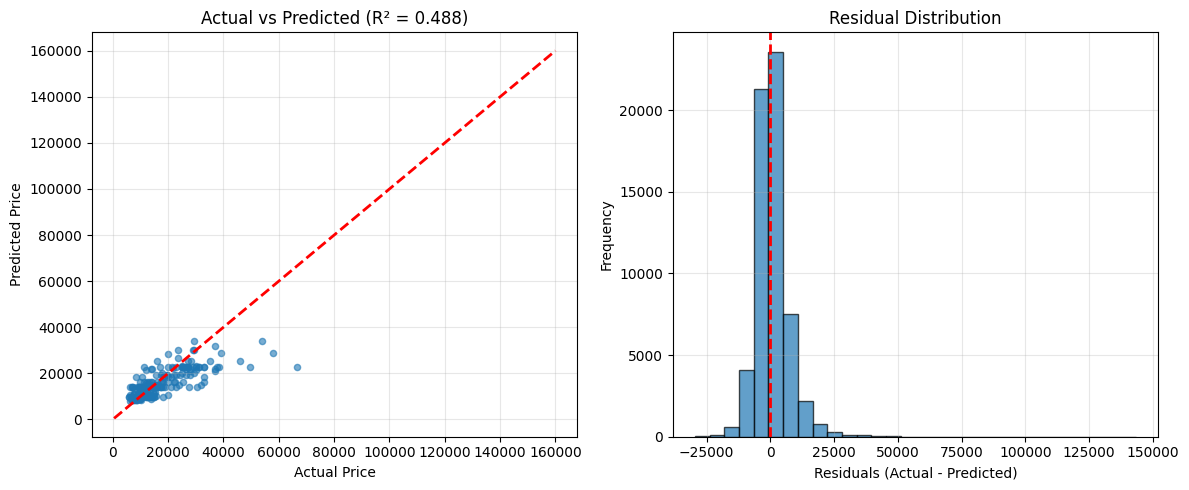

In [ ]:
print("\n" + "="*60)
print("QUICK VISUALIZATION")
print("="*60)

# Create a simple plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(val_target[:200], val_predictions[:200], alpha=0.6, s=20)
axes[0].plot([val_target.min(), val_target.max()], 
             [val_target.min(), val_target.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals histogram
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"✅ SVM Model Complete!")
print(f"\nModel Performance:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE:     {rmse:.2f}")
print(f"  MAE:      {mae:.2f}")

print(f"\nStandard Deviation Analysis:")
print(f"  Target Std Dev:     {val_target.std():.2f}")
print(f"  Predictions Std Dev:{val_predictions.std():.2f}")
print(f"  Std Dev Ratio:      {val_predictions.std() / val_target.std():.4f}")

print(f"\nData Sizes:")
print(f"  Training samples:   {train_features.shape[0]}")
print(f"  Validation samples: {val_features.shape[0]}")
print(f"  Features used:      {train_features.shape[1]}")

if 'test_data_processed' in locals():
    print(f"  Test samples ready:  {test_data_processed.shape[0]}")


FINAL SUMMARY
✅ SVM Model Complete!

Model Performance:
  R² Score: 0.4876
  RMSE:     7003.88
  MAE:      4488.72

Standard Deviation Analysis:
  Target Std Dev:     9784.57
  Predictions Std Dev:6014.89
  Std Dev Ratio:      0.6147

Data Sizes:
  Training samples:   12764
  Validation samples: 60778
  Features used:      18
  Test samples ready:  32567
